# Logistic Regression — Communities & Crime

**Goal:** Classify whether a community has high or low violent crime (`HighViolentCrime`).

All features are already normalized to [0, 1].

In [2]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## 2. Load Data

In [4]:
DATA_PATH = "../Data/communities_crime.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (1994, 102)


,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop,HighViolentCrime
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20,High
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67,High
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43,High
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12,Low
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03,Low


HighViolentCrime
Low     1001
High     993
Name: count, dtype: int64


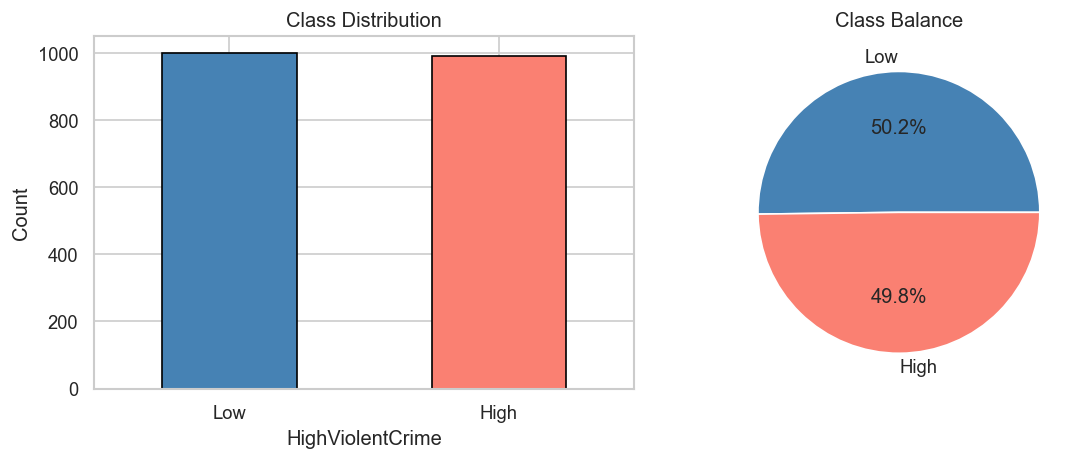

In [5]:
# Class distribution
counts = df["HighViolentCrime"].value_counts()
print(counts)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
counts.plot(kind="bar", ax=axes[0], color=["steelblue", "salmon"], edgecolor="black")
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("HighViolentCrime")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Pie chart
axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%", colors=["steelblue", "salmon"])
axes[1].set_title("Class Balance")

plt.tight_layout()
plt.show()

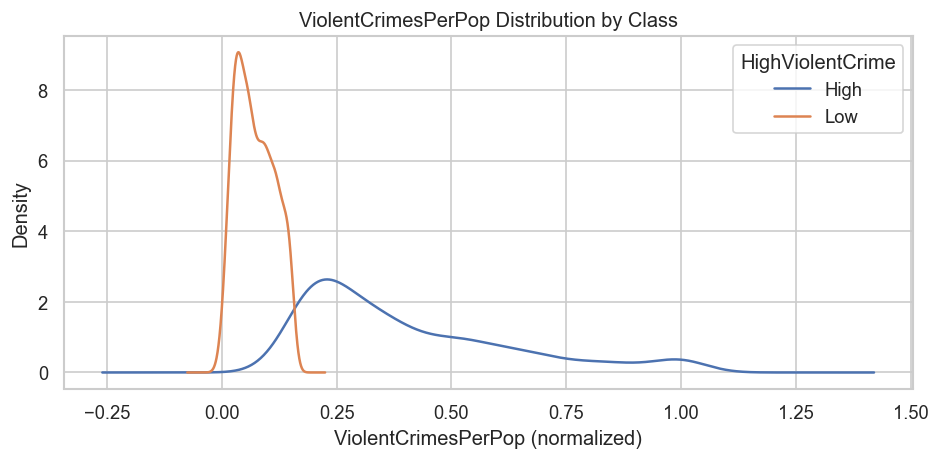

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in df.groupby("HighViolentCrime"):
    grp["ViolentCrimesPerPop"].plot.kde(ax=ax, label=label)
ax.set_title("ViolentCrimesPerPop Distribution by Class")
ax.set_xlabel("ViolentCrimesPerPop (normalized)")
ax.legend(title="HighViolentCrime")
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [8]:
# Drop ViolentCrimesPerPop — it's the continuous version of the target (data leakage)
DROP_COLS = ["ViolentCrimesPerPop"]
TARGET = "HighViolentCrime"

X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET].map({"High": 1, "Low": 0})

# Drop columns that are all-NaN, then fill remaining NaN with column median
X = X.dropna(axis=1, how="all")
X = X.fillna(X.median())

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print(f"Target distribution:\n{y.value_counts()}")

Features: 100  |  Samples: 1994
Target distribution:
HighViolentCrime
0    1001
1     993
Name: count, dtype: int64


In [9]:
# Train / test split  (80 / 20)
TEST_SIZE = 0.2

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Standardize — fit only on training data
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")

Train: (1595, 100)  |  Test: (399, 100)


In [19]:
PENALTY    = "l2"
C          = 1.0
SOLVER     = "lbfgs"
MAX_ITER   = 1000


model = LogisticRegression(
    penalty=PENALTY,
    C=C,
    solver=SOLVER,
    max_iter=MAX_ITER,
    random_state=RANDOM_STATE,
)
model.fit(X_train_sc, y_train)
print("Model trained.")

Model trained.


/Users/shubhaankargupta/Multivariate_Project_32950/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


## Evaluation

In [20]:
y_pred      = model.predict(X_test_sc)
y_pred_prob = model.predict_proba(X_test_sc)[:, 1]  # probability of class 1 (High)

print(classification_report(y_test, y_pred, target_names=["Low", "High"]))

              precision    recall  f1-score   support

         Low       0.83      0.89      0.86       200
        High       0.88      0.81      0.84       199

    accuracy                           0.85       399
   macro avg       0.85      0.85      0.85       399
weighted avg       0.85      0.85      0.85       399



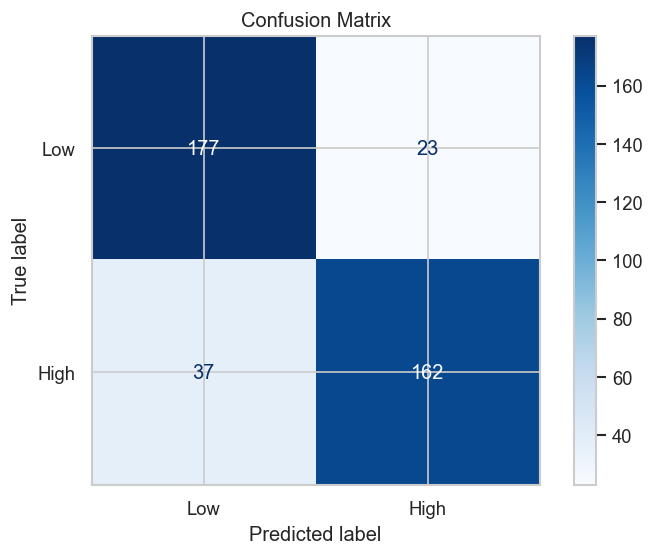

In [21]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Low", "High"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

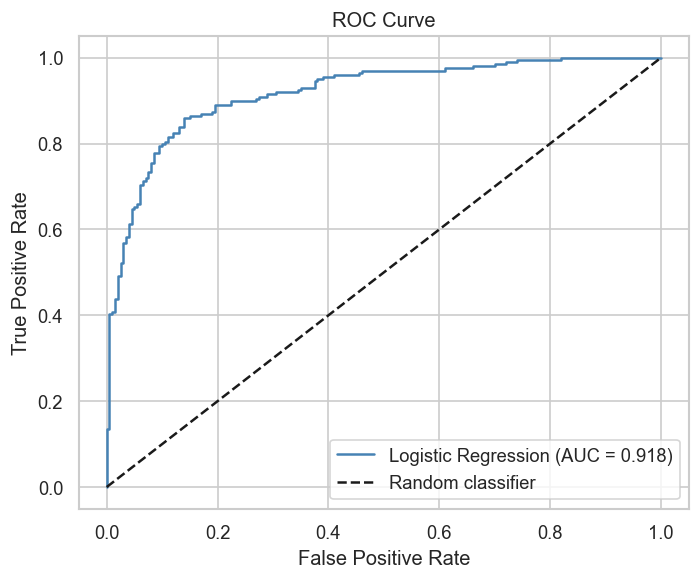

AUC: 0.9184


In [22]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})", color="steelblue")
ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.show()

print(f"AUC: {auc:.4f}")

In [23]:
# Cross-validation accuracy (5-fold, full dataset)
X_sc_full = scaler.fit_transform(X)
cv_scores = cross_val_score(model, X_sc_full, y, cv=5, scoring="accuracy")
print(f"5-fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-fold CV Accuracy: 0.8370 ± 0.0067


/Users/shubhaankargupta/Multivariate_Project_32950/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/shubhaankargupta/Multivariate_Project_32950/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/shubhaankargupta/Multivariate_Project_32950/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:

Top Coefficients

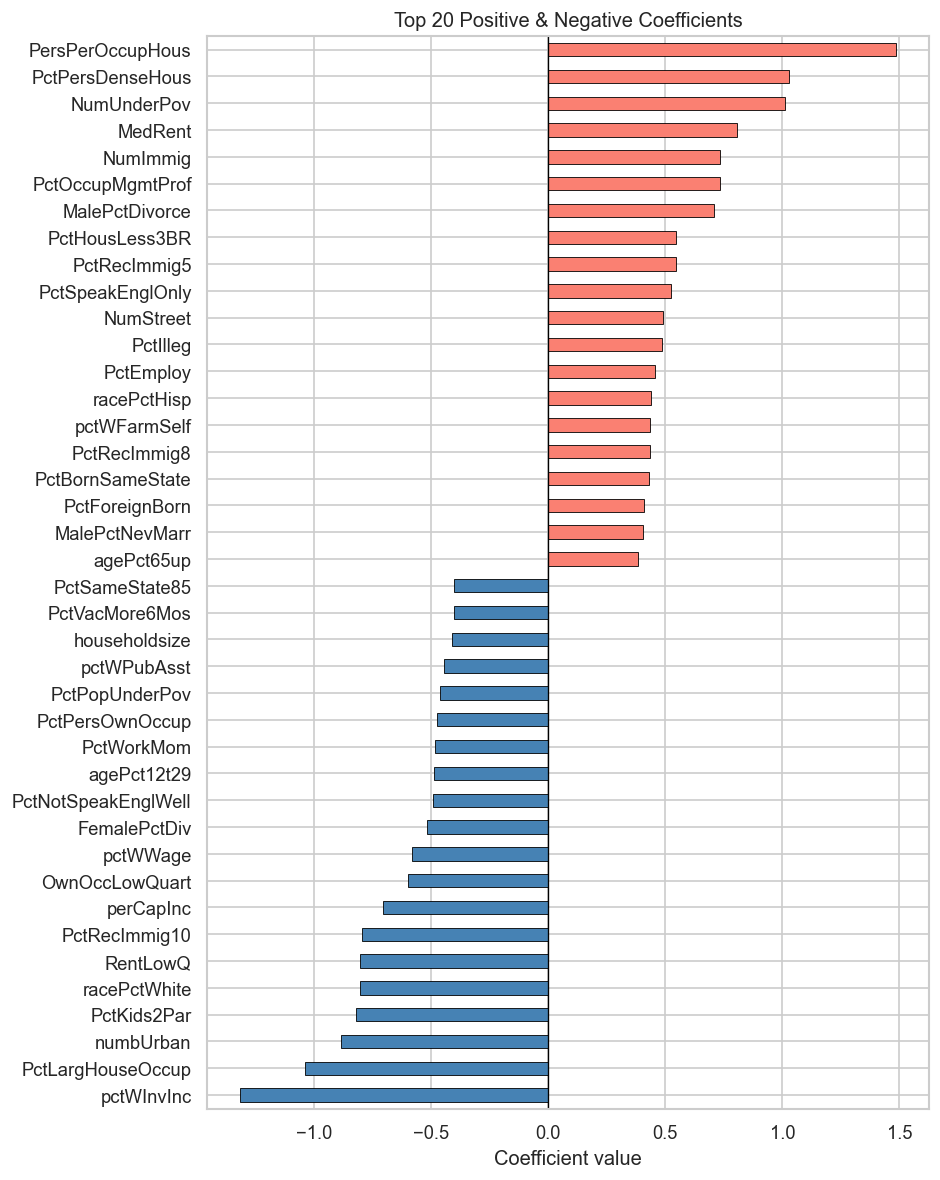

In [ ]:
N_TOP = 20

coef = pd.Series(model.coef_[0], index=X.columns).sort_values()

top_features = pd.concat([coef.head(N_TOP), coef.tail(N_TOP)])

colors = ["salmon" if c > 0 else "steelblue" for c in top_features]

fig, ax = plt.subplots(figsize=(8, 10))
top_features.plot(kind="barh", ax=ax, color=colors, edgecolor="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(f"Top {N_TOP} Positive & Negative Coefficients")
ax.set_xlabel("Coefficient value")
plt.tight_layout()
plt.show()

In [28]:
coef_df = coef.reset_index()
coef_df.columns = ["feature", "coefficient"]
coef_df.head(20)

,feature,coefficient
0,pctWInvInc,-1.313691
1,PctLargHouseOccup,-1.038841
2,numbUrban,-0.885045
3,PctKids2Par,-0.817863
4,racePctWhite,-0.802017
5,RentLowQ,-0.801440
6,PctRecImmig10,-0.792246
7,perCapInc,-0.702612
8,OwnOccLowQuart,-0.597897
9,pctWWage,-0.579168


## 8. Decision Boundary Visualization (Top 2 Features)

Plotting decision boundary using: ['PersPerOccupHous', 'pctWInvInc']


/var/folders/0f/l_wv06ws6k3063l3r6mv6xb80000gn/T/ipykernel_25010/2750371996.py:22: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  legend = ax.legend(*scatter.legend_elements(), title="High Crime", labels=["Low", "High"])


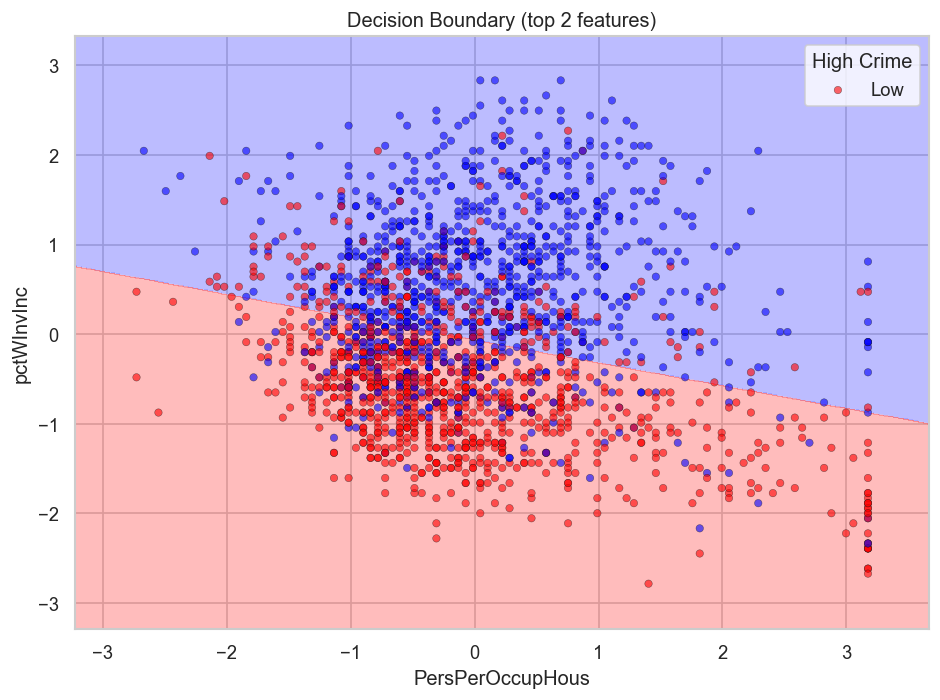

In [17]:
# Project onto the two features with the largest absolute coefficients
top2 = coef_df["feature"].iloc[:2].tolist()
print(f"Plotting decision boundary using: {top2}")

X2 = scaler.fit_transform(X[top2])
model2 = LogisticRegression(C=C, max_iter=MAX_ITER, random_state=RANDOM_STATE)
model2.fit(X2, y)

# Mesh grid
h = 0.01
x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.3, cmap="bwr")
scatter = ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap="bwr", edgecolor="k", linewidth=0.3, alpha=0.6, s=20)
ax.set_xlabel(top2[0])
ax.set_ylabel(top2[1])
ax.set_title("Decision Boundary (top 2 features)")
legend = ax.legend(*scatter.legend_elements(), title="High Crime", labels=["Low", "High"])
plt.tight_layout()
plt.show()